# CHUẨN BỊ DỮ LIỆU THỰC NGHIỆM

## 1. Chuẩn bị vấn đề

## 1.1 Khai báo thư viện

In [5]:
# Load libraries
import os, sys
from IPython import display
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')

## 1.2 Tham số chương trình

In [9]:
# params
seed = 42  # random seed để tái dựng lại thực nghiệm giống nhau

exps_dir = "../exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)

## 1.2 Nạp dữ liệu

In [10]:
data_path  = f"../data/pima-indians-diabetes.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI","DPF","Age","Outcome"]
df_org     = pd.read_csv(data_path, names = data_names)
display(df_org.head())
display(df_org.tail())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## 1.3 Chia dữ liệu
+ Dữ liệu ban đầu: Lấy 70% để làm dữ liệu train, 30% để làm dữ liệu test
+ Dữ liệu train: chia theo chiến lược k-fold với k=5

In [11]:
index_all = np.arange(768)
index_train, index_test = train_test_split(index_all, test_size = 0.33, random_state=seed)

In [12]:
df_train = df_org.iloc[index_train]
df_test  = df_org.iloc[index_test]
print(f'train: {len(df_train)} / test: {len(df_test)} - Tỷ lệ: {len(df_train) / len(df_org)}, {len(df_test) / len(df_org)}')

train: 514 / test: 254 - Tỷ lệ: 0.6692708333333334, 0.3307291666666667


In [14]:
# Lưu dữ liệu sau khi chia
df_train.to_excel(f'{exps_dir}/data/train.xlsx', index=None)
df_test.to_excel(f'{exps_dir}/data/test.xlsx', index=None)
np.savez(f'{exps_dir}/data/idx.npz', id_train = index_train, id_test = index_test)

In [15]:
# Kiểm tra lại
dict(np.load(f'{exps_dir}/data/idx.npz'))

{'id_train': array([464, 223, 393, 766, 570, 671, 412, 755, 176, 525, 333, 163, 248,
        682,  74, 439, 643, 104, 114, 749,  92, 380,  89, 417, 477, 713,
        707, 506,  11,  43,  42, 167, 675, 666, 381, 178, 705, 518, 177,
        532, 539, 257, 616, 440,  15, 478, 256, 388, 360, 367, 446, 589,
        342, 453, 426,   9, 249,  22, 221, 526, 751, 752, 424, 644, 203,
        500,  93, 369, 332, 522, 284, 184, 623, 365, 153,  75, 422, 277,
         68, 695, 188, 271, 236,  88, 654, 117, 125, 633, 289, 238,   0,
        759, 368, 672, 434, 278, 602, 116, 228, 545, 698, 533, 274, 318,
        530, 144, 479, 598, 696, 711, 268, 649, 307, 310, 420,  46, 349,
        371, 595, 261, 195, 767, 645, 107,  59, 578, 664, 100, 445, 689,
        727, 423, 179, 304, 398, 444, 739, 149, 124, 611, 669, 185, 674,
        495, 436, 757, 575, 321, 353, 709, 142, 724, 141, 399, 493, 320,
         19, 172, 627, 312, 390, 715,  12, 407, 408, 305, 354,  25, 576,
        169,  38, 507, 245, 298, 641, 4

In [16]:
pd.read_excel(f'{exps_dir}/data/train.xlsx')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,0,0,22.4,0.207,27,0
511,10,101,86,37,0,45.6,1.136,38,1
512,0,141,0,0,0,42.4,0.205,29,1


In [17]:
pd.read_excel(f'{exps_dir}/data/test.xlsx')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,98,58,33,190,34.0,0.430,43,0
1,2,112,75,32,0,35.7,0.148,21,0
2,2,108,64,0,0,30.8,0.158,21,0
3,8,107,80,0,0,24.6,0.856,34,0
4,7,136,90,0,0,29.9,0.210,50,0
...,...,...,...,...,...,...,...,...,...
249,0,106,70,37,148,39.4,0.605,22,0
250,1,95,82,25,180,35.0,0.233,43,1
251,1,0,74,20,23,27.7,0.299,21,0
252,8,143,66,0,0,34.9,0.129,41,1


## 4. Tiền sử lý dữ liệu

### Làm sạch dữ liệu

### Tạo bảng dữ liệu làm sạch

In [18]:
df_train = pd.read_excel(f'{exps_dir}/data/train.xlsx')

### Xóa dữ liệu trùng nhau

In [20]:
display(df_train[df_train.duplicated(keep = False)])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome


In [21]:
df_train.drop_duplicates(ignore_index=True, inplace=True)
display(df_train)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,0,0,22.4,0.207,27,0
511,10,101,86,37,0,45.6,1.136,38,1
512,0,141,0,0,0,42.4,0.205,29,1


### Sử lý giá trị rỗng hoặc không hợp lệ

In [23]:
print("="*5, "Null Value", "="*5)
display(df_train.isnull().sum())

print("="*5, "Checking NaN", "="*5)
display(df_train.isna().sum())

===== Null Value =====


Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

===== Checking NaN =====


Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

In [27]:
#thay giá trị 0 bằng median
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
medians = df_train[cols_with_zero].replace(0, pd.NA).median()
df_train[cols_with_zero] = df_train[cols_with_zero].replace(0, pd.NA)
df_train[cols_with_zero] = df_train[cols_with_zero].fillna(medians)
display(df_train)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,10,115.0,98.0,29.0,125.0,24.0,1.022,34,0
1,7,142.0,60.0,33.0,190.0,28.8,0.687,61,0
2,4,116.0,72.0,12.0,87.0,22.1,0.463,37,0
3,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1
4,3,78.0,70.0,29.0,125.0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0
510,1,96.0,122.0,29.0,125.0,22.4,0.207,27,0
511,10,101.0,86.0,37.0,125.0,45.6,1.136,38,1
512,0,141.0,72.0,29.0,125.0,42.4,0.205,29,1


## Biến đổi dữ liệu

#### Chuyển đổi dữ liệu danh mục thành dữ liệu số

In [32]:
# Class: LabelEncoder
class_encoder = LabelEncoder()
class_encoder.fit(df_train["Outcome"])
class_names = class_encoder.classes_
print(class_names)

# Save encoders
joblib.dump(class_encoder, f'{save_dir}/class_encoder.joblib')

# Load and check again
print(joblib.load(f'{save_dir}/class_encoder.joblib').classes_)

[0 1]
[0 1]


In [34]:
class_encoder.transform(df_train["Outcome"])

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [37]:
df_train["Outcome"] = class_encoder.transform(df_train["Outcome"])
display(df_train)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,10,115.0,98.0,29.0,125.0,24.0,1.022,34,0
1,7,142.0,60.0,33.0,190.0,28.8,0.687,61,0
2,4,116.0,72.0,12.0,87.0,22.1,0.463,37,0
3,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1
4,3,78.0,70.0,29.0,125.0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0
510,1,96.0,122.0,29.0,125.0,22.4,0.207,27,0
511,10,101.0,86.0,37.0,125.0,45.6,1.136,38,1
512,0,141.0,72.0,29.0,125.0,42.4,0.205,29,1


#### Chuẩn hóa dữ liệu

##### Min-Max Normalization

In [59]:
# Min-Max Normalization
scale_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DPF", "Age"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_train[scale_columns])
df_minmax = df_train.copy()
df_minmax[scale_columns] = minmax_scaler.transform(df_train[scale_columns])
display(df_minmax)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,0.588235,0.458065,0.755102,0.381818,0.133413,0.118609,0.403074,0.216667,0
1,0.411765,0.632258,0.367347,0.454545,0.211538,0.216769,0.260034,0.666667,0
2,0.235294,0.464516,0.489796,0.072727,0.087740,0.079755,0.164389,0.266667,0
3,0.058824,0.529032,0.367347,0.381818,0.133413,0.243354,0.115713,0.433333,1
4,0.176471,0.219355,0.469388,0.381818,0.133413,0.292434,0.081981,0.300000,0
...,...,...,...,...,...,...,...,...,...
509,0.294118,0.612903,0.408163,0.490909,0.151442,0.212679,0.142186,0.083333,0
510,0.058824,0.335484,1.000000,0.381818,0.133413,0.085890,0.055081,0.100000,0
511,0.588235,0.367742,0.632653,0.527273,0.133413,0.560327,0.451751,0.283333,1
512,0.000000,0.625806,0.489796,0.381818,0.133413,0.494888,0.054227,0.133333,1


In [60]:
minmax_scaler.__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 514,
 'scale_': array([0.05882353, 0.00645161, 0.01020408, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.24489796, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 24.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  98.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

In [61]:
# Save encoders
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')

['../exps/feature1/minmax_scaler.joblib']

In [62]:
joblib.load(f'{save_dir}/minmax_scaler.joblib').__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 514,
 'scale_': array([0.05882353, 0.00645161, 0.01020408, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.24489796, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 24.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  98.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

In [63]:
# save scale_columns
np.savez(f'{save_dir}/scale_columns.npz', scale_columns = scale_columns)
dict(np.load(f'{save_dir}/scale_columns.npz'))

{'scale_columns': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype='<U13')}

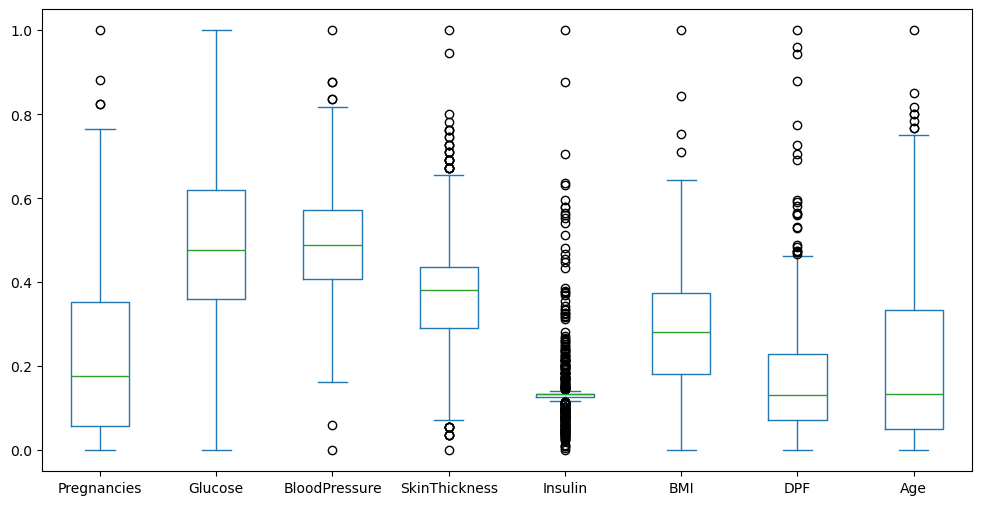

In [64]:
df_minmax[scale_columns].plot(kind="box", figsize=(12,6));

##### Standard Normalization

In [66]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(df_train[scale_columns])
df_standard = df_train.copy()
df_standard[scale_columns] = standard_scaler.transform(df_train[scale_columns])
display(df_standard)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,1.899177,-0.236584,2.110271,0.027836,-0.175509,-1.190856,1.606615,0.069059,0
1,0.982866,0.648884,-1.035166,0.496932,0.571180,-0.500599,0.626098,2.372893,0
2,0.066554,-0.203789,-0.041870,-1.965825,-0.612035,-1.464083,-0.029531,0.325040,0
3,-0.849757,0.124162,-1.035166,0.027836,-0.175509,-0.313654,-0.363200,1.178312,1
4,-0.238883,-1.450004,-0.207420,0.027836,-0.175509,0.031475,-0.594426,0.495695,0
...,...,...,...,...,...,...,...,...,...
509,0.371991,0.550499,-0.704068,0.731480,-0.003196,-0.529360,-0.181731,-0.613559,0
510,-0.849757,-0.859691,4.096863,0.027836,-0.175509,-1.420942,-0.778822,-0.528232,0
511,1.899177,-0.695716,1.116975,0.966029,-0.175509,1.915302,1.940284,0.410367,1
512,-1.155194,0.616089,-0.041870,0.027836,-0.175509,1.455131,-0.784676,-0.357577,1


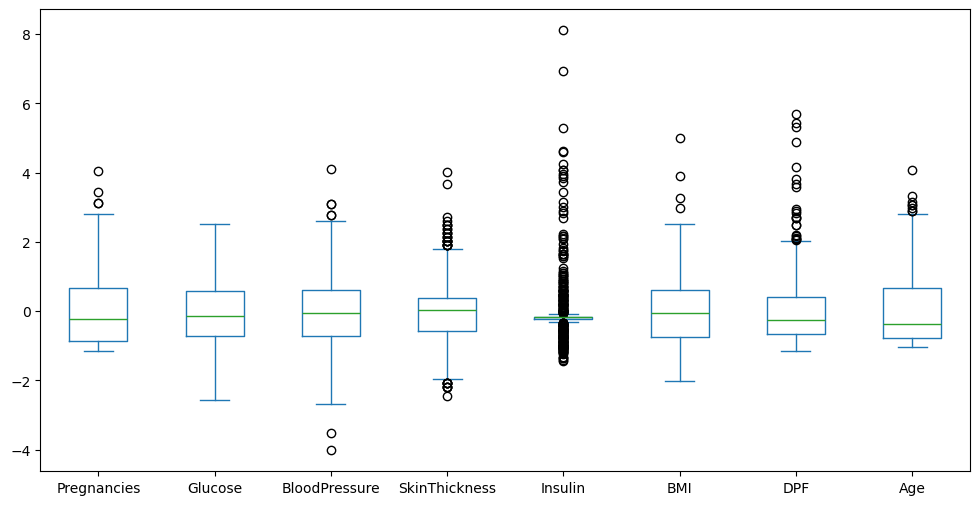

In [67]:
df_standard[scale_columns].plot(kind="box", figsize=(12,6));

In [68]:
correlations = df_standard.corr(method='pearson')
display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
Pregnancies,1.000000,0.136299,0.178632,0.101356,0.032440,0.038102,-0.018125,0.540325,0.197141
Glucose,0.136299,1.000000,0.206803,0.123463,0.422437,0.233897,0.182870,0.276418,0.521259
BloodPressure,0.178632,0.206803,1.000000,0.190345,0.016834,0.253696,0.028434,0.333269,0.170032
SkinThickness,0.101356,0.123463,0.190345,1.000000,0.108270,0.572538,0.137600,0.111149,0.212398
Insulin,0.032440,0.422437,0.016834,0.108270,1.000000,0.125587,0.129115,0.118214,0.222325
BMI,0.038102,0.233897,0.253696,0.572538,0.125587,1.000000,0.180665,0.031319,0.341258
DPF,-0.018125,0.182870,0.028434,0.137600,0.129115,0.180665,1.000000,0.042581,0.150681
Age,0.540325,0.276418,0.333269,0.111149,0.118214,0.031319,0.042581,1.000000,0.281967
Outcome,0.197141,0.521259,0.170032,0.212398,0.222325,0.341258,0.150681,0.281967,1.000000


In [69]:
standard_scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(514),
 'mean_': array([  3.78210117, 122.21400778,  72.50583658,  28.76264591,
        140.27821012,  32.2811284 ,   0.47308949,  33.19066148]),
 'var_': array([1.07190571e+01, 9.29782994e+02, 1.45950355e+02, 7.27102000e+01,
        7.57787007e+03, 4.83570952e+01, 1.16729167e-01, 1.37348862e+02]),
 'scale_': array([ 3.27399711, 30.49234321, 12.08099148,  8.52702762, 87.05096249,
         6.9539266 ,  0.3416565 , 11.71959309])}

In [70]:
# Save encoders
joblib.dump(standard_scaler, f'{save_dir}/standard_scaler.joblib')

['../exps/feature1/standard_scaler.joblib']

In [71]:
joblib.load(f'{save_dir}/standard_scaler.joblib').__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DPF', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(514),
 'mean_': array([  3.78210117, 122.21400778,  72.50583658,  28.76264591,
        140.27821012,  32.2811284 ,   0.47308949,  33.19066148]),
 'var_': array([1.07190571e+01, 9.29782994e+02, 1.45950355e+02, 7.27102000e+01,
        7.57787007e+03, 4.83570952e+01, 1.16729167e-01, 1.37348862e+02]),
 'scale_': array([ 3.27399711, 30.49234321, 12.08099148,  8.52702762, 87.05096249,
         6.9539266 ,  0.3416565 , 11.71959309])}

### Lưu dữ liệu Features

In [73]:
# MinMax
x_train = df_minmax.values[:, :-1]
y_train = df_minmax.values[:, -1]
display(df_minmax.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_minmax.npz', x_train = x_train, y_train = y_train)
df_minmax.to_excel(f'{save_dir}/df_minmax.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,0.588235,0.458065,0.755102,0.381818,0.133413,0.118609,0.403074,0.216667,0
1,0.411765,0.632258,0.367347,0.454545,0.211538,0.216769,0.260034,0.666667,0
2,0.235294,0.464516,0.489796,0.072727,0.087740,0.079755,0.164389,0.266667,0
3,0.058824,0.529032,0.367347,0.381818,0.133413,0.243354,0.115713,0.433333,1
4,0.176471,0.219355,0.469388,0.381818,0.133413,0.292434,0.081981,0.300000,0


+ x_train: 
  [[0.58823529 0.45806452 0.75510204 0.38181818 0.13341346 0.11860941
  0.4030743  0.21666667]
 [0.41176471 0.63225806 0.36734694 0.45454545 0.21153846 0.21676892
  0.26003416 0.66666667]
 [0.23529412 0.46451613 0.48979592 0.07272727 0.08774038 0.0797546
  0.16438941 0.26666667]
 [0.05882353 0.52903226 0.36734694 0.38181818 0.13341346 0.24335378
  0.11571307 0.43333333]
 [0.17647059 0.21935484 0.46938776 0.38181818 0.13341346 0.29243354
  0.08198121 0.3       ]]
+ y_train: 
  [0. 0. 0. 1. 0.]


In [74]:
# Standard
x_train = df_standard.values[:, :-1]
y_train = df_standard.values[:, -1]
display(df_standard.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_standard.npz', x_train = x_train, y_train = y_train)
df_minmax.to_excel(f'{save_dir}/df_standard.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,1.899177,-0.236584,2.110271,0.027836,-0.175509,-1.190856,1.606615,0.069059,0
1,0.982866,0.648884,-1.035166,0.496932,0.571180,-0.500599,0.626098,2.372893,0
2,0.066554,-0.203789,-0.041870,-1.965825,-0.612035,-1.464083,-0.029531,0.325040,0
3,-0.849757,0.124162,-1.035166,0.027836,-0.175509,-0.313654,-0.363200,1.178312,1
4,-0.238883,-1.450004,-0.207420,0.027836,-0.175509,0.031475,-0.594426,0.495695,0


+ x_train: 
  [[ 1.89917664 -0.23658424  2.11027079  0.0278355  -0.1755088  -1.19085646
   1.60661512  0.06905859]
 [ 0.98286551  0.64888395 -1.03516641  0.49693214  0.57118024 -0.50059896
   0.62609815  2.37289284]
 [ 0.06655438 -0.20378912 -0.04187045 -1.96582522 -0.6120347  -1.46408339
  -0.02953111  0.32504017]
 [-0.84975676  0.12416206 -1.03516641  0.0278355  -0.1755088  -0.31365422
  -0.36319957  1.17831211]
 [-0.23888267 -1.45000361 -0.20741978  0.0278355  -0.1755088   0.03147453
  -0.59442596  0.49569456]]
+ y_train: 
  [0. 0. 0. 1. 0.]


# Kết thúc

In [78]:
!jupyter nbconvert --to html preprocessing.ipynb

[NbConvertApp] Converting notebook preprocessing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 465340 bytes to preprocessing.html
